# IND320 Project Work [Part-1]
## Dashboard Basics

Student name: Emre Can Emer

GitHub Repository link: https://github.com/Emriey/IND320_project

StreamLit Share link: https://emriey.streamlit.app/

*Screencast and .pdf files can be found in the GitHub repository.*

## AI Usage
Google Gemini was briefly used for this assignment. I prefer to ask small questions if I feel like I'm stuck and look for guidance rather than direct solutions.

*I do not have copilot enabled in VsCode.*

A few examples of the questions I asked AI:

* Would caching the data in the code for homepage be enough or would I need to cache it on every page?
* Fixing a permission denied error for python pathing for files. I solved it by making a copy of the .csv in the streamlit folder instead.
* How do I mark columns with months? (For the slider plotting on the plots page)

## Description
I used the jupyter notebook to only test the initial processing and plotting etc... I have a cell here which I can use to run the local streamlit-app (.py files in the streamlit folder) for testing purposes.

I used the teacher's example projects to initially set everything up. uv.lock, requirements.txt .streamlit config files are all taken from lecture material.

Loading the data from reservoir.csv file with pandas, pre-processing and plotting can be found below. However, all the streamlit-app features such as sliders and drop-down menus are in the .py files.

I made a barebones app here first as suggested in the project work. GitHub and streamlit share were already set up before any meaningful work. Afterwards, I continued with loading the data and pre-processing it.

Pre-propressing just includes renaming the column names and sorting the data according to date.

Lastly, organized data was plotted, separately and all-together, as requested. There is also a logarithmic plot of all the columns at the end. I thought making a log plot of all the columns would provide better readability without actually scaling the data.

The streamlit app has its own folder. For the homepage sidebar, I choose to use the older method. All the corresponding python code files for the pages are in the pages folder. Streamlit automatically creates a sidebar from these files.

I choose to read the .csv file data at homepage and cache it there. This way I didn't need to load the data at every page. It is stored as session_state and used by other pages aswell.

Second page is simple, it shows a table of the loaded data and provides a first month trend visual. Third page provide the plots of the columns. All together in the same or separate. Depending on user choice. The last "About" page is there solely for testing purposes.

## Initialization

In [1]:
# Importing the necessary libraries.
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# Path to be used below in test runs.
path_prefix = "C:/Users/emryc/Documents/Dokumenter/NMBU/Kurs/_IND320/IND320_project/streamlit/"

In [18]:
# This cell is used when I need to test my work.
file_name = "Home_page.py"
!uv run streamlit run {path_prefix}{file_name}

^C


## Loading the data

In [7]:
# Loading the data with pandas and printing it.
reservoir_df = pd.read_csv('data/reservoirs.csv')
print(reservoir_df.dtypes)
reservoir_df

dato_Id                         str
omrType                         str
omrnr                         int64
iso_aar                       int64
iso_uke                       int64
fyllingsgrad                float64
kapasitet_TWh               float64
fylling_TWh                 float64
neste_Publiseringsdato          str
fyllingsgrad_forrige_uke    float64
endring_fyllingsgrad        float64
dtype: object


,dato_Id,omrType,omrnr,iso_aar,iso_uke,fyllingsgrad,kapasitet_TWh,fylling_TWh,neste_Publiseringsdato,fyllingsgrad_forrige_uke,endring_fyllingsgrad
0,1995-09-03,EL,4,1995,35,0.944721,21.079208,19.913979,0001-01-01T00:00:00,0.936888,0.007833
1,2020-11-15,EL,1,2020,46,0.974361,6.003264,5.849344,2020-11-25T13:00:00,0.997406,-0.023046
2,2011-08-28,EL,4,2011,34,0.786499,21.079208,16.578772,0001-01-01T00:00:00,0.787193,-0.000694
3,1998-07-05,EL,3,1998,27,0.793969,8.920932,7.082947,0001-01-01T00:00:00,0.733812,0.060157
4,2011-03-27,EL,4,2011,12,0.300820,21.079208,6.341054,0001-01-01T00:00:00,0.311122,-0.010301
...,...,...,...,...,...,...,...,...,...,...,...
14872,2026-07-19,VASS,3,2026,29,0.796849,28.155403,22.435612,2026-07-29T13:00:00,0.794957,0.001892
14873,2026-09-06,VASS,3,2026,36,0.826252,28.155403,23.263466,2026-09-16T13:00:00,0.827641,-0.001389
14874,2026-08-30,VASS,3,2026,35,0.827718,28.155403,23.304743,2026-09-09T13:00:00,0.829898,-0.002180
14875,2026-09-06,VASS,1,2026,36,0.570397,36.044464,20.559645,2026-09-16T13:00:00,0.567087,0.003310


## Renaming columns and sorting

In [8]:
# Rename the columns.
reservoir_df = reservoir_df.rename(columns={"dato_Id": "date_Id", "omrType": "areaType", "omrnr": "areaNr", "iso_aar": "iso_year",
                                            "iso_uke": "iso_week", "fyllingsgrad": "fill_level", "kapasitet_TWh": "capacity_TWh",
                                            "fylling_TWh": "fill_TWh", "neste_Publiseringsdato": "next_publishdate",
                                            "fyllingsgrad_forrige_uke": "fill_level_lastweek", "endring_fyllingsgrad": "fill_level_change"})
reservoir_df

,date_Id,areaType,areaNr,iso_year,iso_week,fill_level,capacity_TWh,fill_TWh,next_publishdate,fill_level_lastweek,fill_level_change
0,1995-09-03,EL,4,1995,35,0.944721,21.079208,19.913979,0001-01-01T00:00:00,0.936888,0.007833
1,2020-11-15,EL,1,2020,46,0.974361,6.003264,5.849344,2020-11-25T13:00:00,0.997406,-0.023046
2,2011-08-28,EL,4,2011,34,0.786499,21.079208,16.578772,0001-01-01T00:00:00,0.787193,-0.000694
3,1998-07-05,EL,3,1998,27,0.793969,8.920932,7.082947,0001-01-01T00:00:00,0.733812,0.060157
4,2011-03-27,EL,4,2011,12,0.300820,21.079208,6.341054,0001-01-01T00:00:00,0.311122,-0.010301
...,...,...,...,...,...,...,...,...,...,...,...
14872,2026-07-19,VASS,3,2026,29,0.796849,28.155403,22.435612,2026-07-29T13:00:00,0.794957,0.001892
14873,2026-09-06,VASS,3,2026,36,0.826252,28.155403,23.263466,2026-09-16T13:00:00,0.827641,-0.001389
14874,2026-08-30,VASS,3,2026,35,0.827718,28.155403,23.304743,2026-09-09T13:00:00,0.829898,-0.002180
14875,2026-09-06,VASS,1,2026,36,0.570397,36.044464,20.559645,2026-09-16T13:00:00,0.567087,0.003310


In [ ]:
# print contents in a relevant way?
# Converting the "date_Id" column to datetime.
reservoir_df['date_Id'] = pd.to_datetime(reservoir_df['date_Id'])

# Sorting the dataframe according to date.
reservoir_df = reservoir_df.sort_values(by='date_Id').reset_index(drop=True)
reservoir_df

,date_Id,areaType,areaNr,iso_year,iso_week,fill_level,capacity_TWh,fill_TWh,next_publishdate,fill_level_lastweek,fill_level_change
0,1995-01-08,EL,5,1995,1,0.616448,17.390587,10.720388,0001-01-01T00:00:00,0.614288,0.002160
1,1995-01-08,EL,4,1995,1,0.558864,21.079208,11.780413,0001-01-01T00:00:00,0.801348,-0.242484
2,1995-01-08,EL,3,1995,1,0.602376,8.920932,5.373754,0001-01-01T00:00:00,0.596027,0.006349
3,1995-01-08,EL,1,1995,1,0.621467,6.003264,3.730831,0001-01-01T00:00:00,0.734888,-0.113421
4,1995-01-08,EL,2,1995,1,0.630947,34.043590,21.479713,0001-01-01T00:00:00,0.777604,-0.146657
...,...,...,...,...,...,...,...,...,...,...,...
14872,2026-09-06,EL,4,2026,36,0.902762,21.079208,19.029512,2026-09-16T13:00:00,0.906918,-0.004156
14873,2026-09-06,VASS,1,2026,36,0.570397,36.044464,20.559645,2026-09-16T13:00:00,0.567087,0.003310
14874,2026-09-06,VASS,3,2026,36,0.826252,28.155403,23.263466,2026-09-16T13:00:00,0.827641,-0.001389
14875,2026-09-06,EL,2,2026,36,0.460863,34.043590,15.689445,2026-09-16T13:00:00,0.458999,0.001865


## Plotting the data

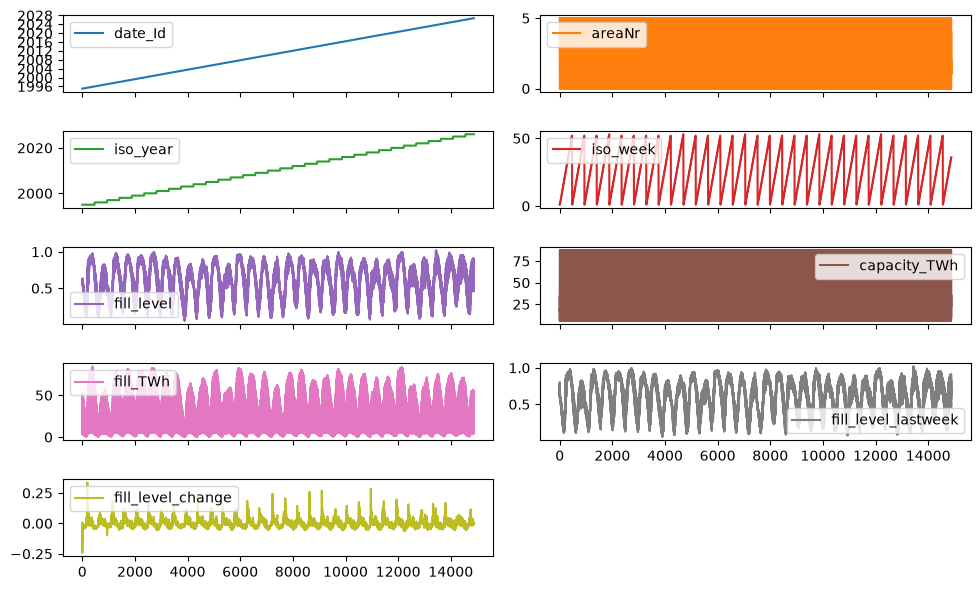

In [10]:
# Plotting the data.
# Using subplots to plot every column.
reservoir_df.plot(subplots=True, layout=(5,2), figsize=(10,6), sharex=True)

plt.tight_layout()
plt.show()

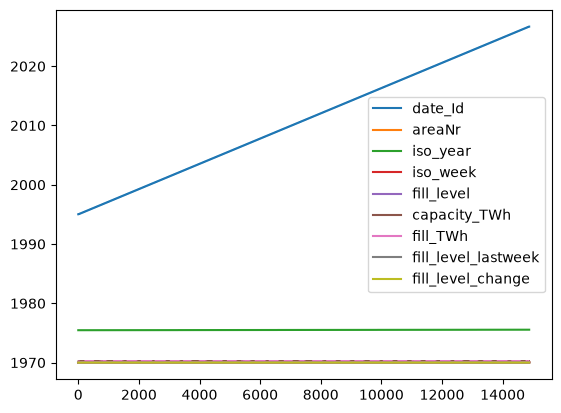

In [16]:
# Plotting everything together.
reservoir_df.plot()
plt.show()

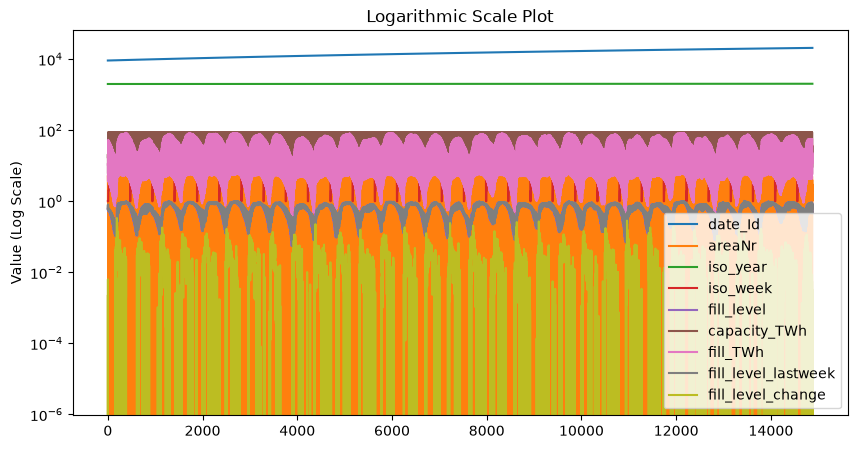

In [ ]:
# Ploting the dataframe with log.
# I thought logarithmic plotting would give better readability without actully having to scale the data.
ax = reservoir_df.plot(figsize=(10, 5))
ax.set_yscale('log')

plt.title("Logarithmic Scale Plot")
plt.ylabel("Value (Log Scale)")
plt.show()